<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Reinforcement_Learning/Upper_Confidence_Bound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Stepwise Procedure

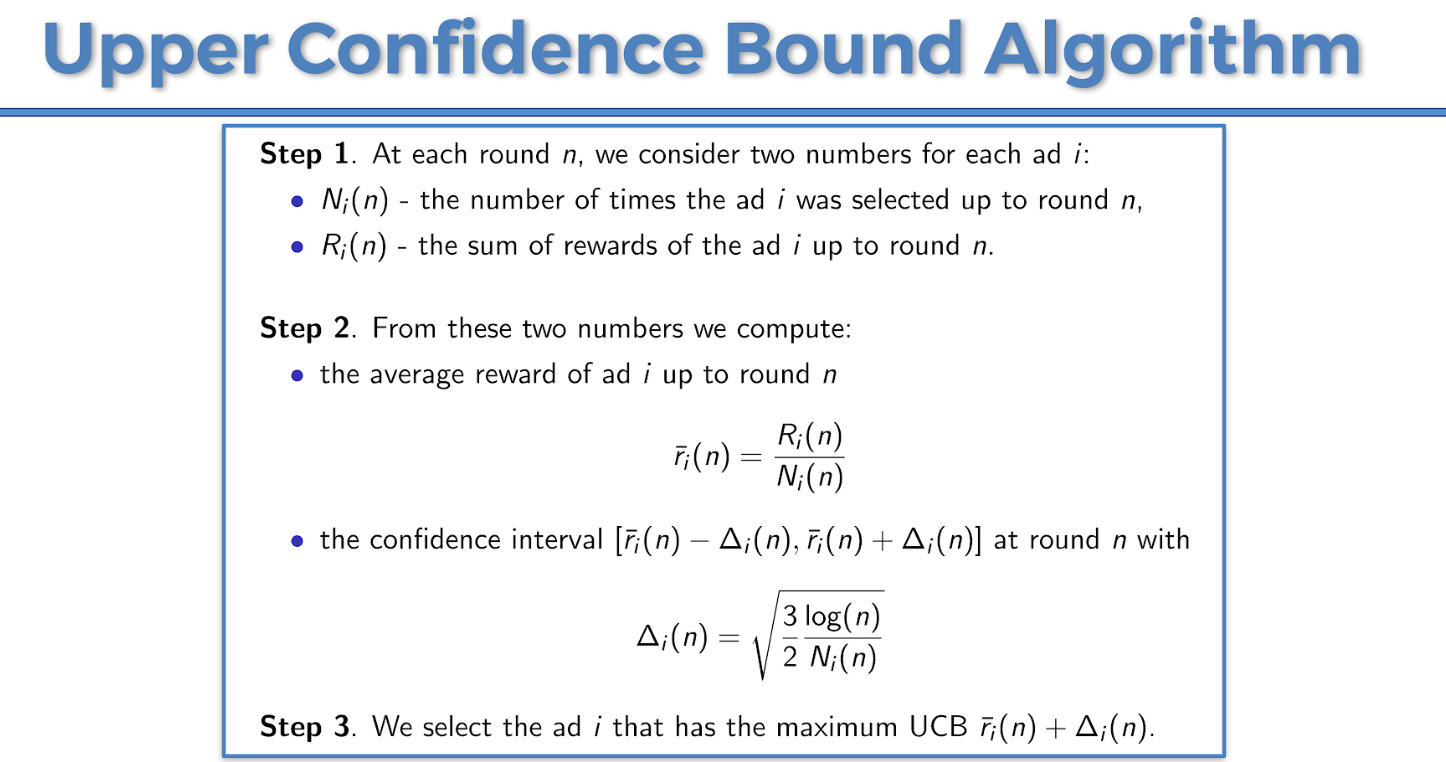

##Importing Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

##Importing datasets

In [22]:
df = pd.read_csv("/content/Ads_CTR_Optimisation.csv")

##Implementing UCB

In [23]:
N = len(df)                             # Total no. of rounds/iterations in which we'll select an ad
d = df.columns.size                     # Total no. of ads
ads_selected = []                       # Keeps a track of which ad is chosen in each round
numbers_of_selections = [0] * d         # How many times each ad has been selected
sums_of_rewards = [0] * d               # Accumulate the total reward received from each ad over the rounds
total_reward = 0                        # Rewards recieved from selecting different ads
for n in range(0, N):
  ad = 0                                # ad number
  max_upper_bound = 0

  for i in range(0, d):
    if (numbers_of_selections[i] > 0):
      average_reward = sums_of_rewards[i] / numbers_of_selections[i]
      delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections[i])
      upper_bound = average_reward + delta_i
    else :
      upper_bound = 1e400
    if (upper_bound > max_upper_bound) :
      max_upper_bound = upper_bound
      ad = i

  ads_selected.append(ad)
  numbers_of_selections[ad] += 1
  reward = df.values[n, ad]
  sums_of_rewards[ad] += reward
  total_reward += reward


##Visualising the results

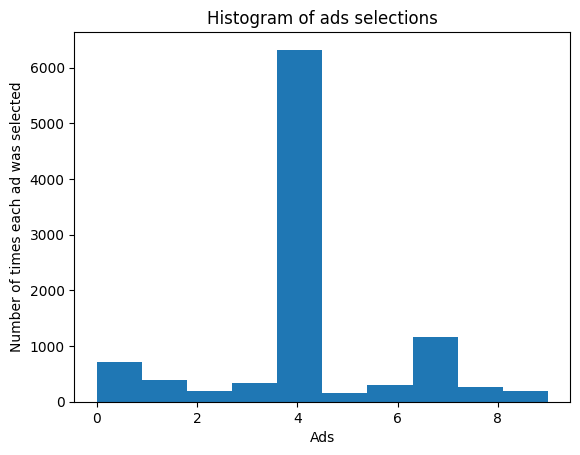

In [26]:
plt.hist(ads_selected)
plt.title("Histogram of ads selections")
plt.xlabel("Ads")
plt.ylabel("Number of times each ad was selected")
plt.show()